<a href="https://colab.research.google.com/github/Sigurd-RW/lis4693/blob/main/lab5/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
!pip install gensim
!pip install pyldavis
!pip install nltk

In [135]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [136]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

In [137]:
import requests
import io

url = "https://raw.githubusercontent.com/Sigurd-RW/lis4693/refs/heads/main/lab5/toy%20lens-export.csv"

response = requests.get(url)
response.raise_for_status()

text = response.text


The search query I used was (Toys AND (Company AND (Sales AND (Children AND (Play AND Toy))))). Then from that I used the filters to filter out only files that has open access, full text, and an abstract. Then I filtered it down to only the four major English-speaking countries: the US, UK, Ireland, Canada, and Australia. My overall goal is to find out common topics in the toy industry.

In [138]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(io.StringIO(text), on_bad_lines='skip')
print(df.head(10))

               Lens ID                                              Title  \
0  000-136-577-480-823  The Constructs of the Living Labs Innovation P...   
1  000-191-003-958-113  Succession planning and exit strategy: creatin...   
2  000-390-008-800-376              Ding: the life of Jay Norwood Darling   
3  000-479-021-112-560  Selling Marvelâ€™s Cinematic Superheroes Throu...   
4  000-514-804-485-84X  The impact of neglecting user-centered informa...   
5  000-670-734-279-251  Case study of Family Food Aides in Expanded Nu...   
6  000-713-201-012-930  Visual representation of the buying act by chi...   
7  000-789-663-719-00X                                Markets: Gift Cards   
8  000-892-930-104-700  Setting the future of digital and social media...   
9  000-944-314-393-977  An Empirical Test of the Theory of Sales: Do H...   

  Date Published  Publication Year Publication Type  \
0     2015-01-01            2015.0     dissertation   
1     2013-01-01            2013.0     dis

In [139]:
df_text = df[["Title"]].copy()
df_text.head(10)

,Title
0,The Constructs of the Living Labs Innovation P...
1,Succession planning and exit strategy: creatin...
2,Ding: the life of Jay Norwood Darling
3,Selling Marvelâ€™s Cinematic Superheroes Throu...
4,The impact of neglecting user-centered informa...
5,Case study of Family Food Aides in Expanded Nu...
6,Visual representation of the buying act by chi...
7,Markets: Gift Cards
8,Setting the future of digital and social media...
9,An Empirical Test of the Theory of Sales: Do H...


Using the Title column because it contains the most semantic content. It's easy to read and gives a description of the topic at hand.

In [140]:
docs = df.Title.tolist()
print(docs[0])

The Constructs of the Living Labs Innovation Platform


In [141]:
stop_words = stopwords.words('english')

In [142]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

In [143]:
## Adding custom stopwords

custom_stopwords = ['mr.', '16', 'june', '30', '7']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['mr.', '16', 'june', '30', '7']


In [144]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
The Constructs of the Living Labs Innovation Platform

Cleaned document with custom stopwords:
['constructs', 'living', 'labs', 'innovation', 'platform']


In [145]:
cleaned_docs = [clean_doc(doc) for doc in docs]

In [146]:
id2word = corpora.Dictionary(cleaned_docs)

In [147]:
lda_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
lda_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)

In [148]:
print("\n--- Top words for all topics in lda_10 model ---")
for i in range(lda_10.num_topics):
    terms = lda_10.get_topic_terms(i, 5)
    print(f"Topic {i}:")
    for num, prob in terms:
        print(f"  {id2word[num]} (probability: {prob:.4f})")
    print()


--- Top words for all topics in lda_10 model ---
Topic 0:
  health (probability: 0.0096)
  cultural (probability: 0.0062)
  policy (probability: 0.0048)
  china (probability: 0.0048)
  food (probability: 0.0046)

Topic 1:
  advertising (probability: 0.0076)
  analysis (probability: 0.0048)
  business (probability: 0.0048)
  childrens (probability: 0.0048)
  food (probability: 0.0048)

Topic 2:
  policy (probability: 0.0067)
  global (probability: 0.0055)
  food (probability: 0.0047)
  development (probability: 0.0046)
  health (probability: 0.0046)

Topic 3:
  health (probability: 0.0090)
  challenges (probability: 0.0077)
  us (probability: 0.0050)
  social (probability: 0.0050)
  empirical (probability: 0.0040)

Topic 4:
  market (probability: 0.0052)
  role (probability: 0.0052)
  children (probability: 0.0045)
  marketing (probability: 0.0044)
  new (probability: 0.0043)

Topic 5:
  study (probability: 0.0099)
  food (probability: 0.0094)
  marketing (probability: 0.0080)
  case (

In [149]:
print("\n--- Top words for all topics in lda_20 model ---")
for i in range(lda_20.num_topics):
    terms = lda_20.get_topic_terms(i, 5)
    print(f"Topic {i}:")
    for num, prob in terms:
        print(f"  {id2word[num]} (probability: {prob:.4f})")
    print()


--- Top words for all topics in lda_20 model ---
Topic 0:
  study (probability: 0.0144)
  food (probability: 0.0115)
  consumer (probability: 0.0087)
  social (probability: 0.0078)
  marketing (probability: 0.0072)

Topic 1:
  food (probability: 0.0085)
  advertising (probability: 0.0085)
  study (probability: 0.0073)
  care (probability: 0.0064)
  rise (probability: 0.0064)

Topic 2:
  economic (probability: 0.0064)
  case (probability: 0.0064)
  urban (probability: 0.0064)
  development (probability: 0.0064)
  support (probability: 0.0064)

Topic 3:
  commercial (probability: 0.0067)
  market (probability: 0.0067)
  impact (probability: 0.0067)
  regulation (probability: 0.0067)
  information (probability: 0.0050)

Topic 4:
  learning (probability: 0.0077)
  autism (probability: 0.0075)
  worlds (probability: 0.0057)
  music (probability: 0.0057)
  health (probability: 0.0057)

Topic 5:
  review (probability: 0.0084)
  culture (probability: 0.0061)
  product (probability: 0.0053)
  

The second model has a lot more specific topics rather than the broad categories of model 1. Therefore we should go forward with this one.

Task 4: Labeled Topics

Based on the top words for the visualized topics from the lda_20 model (using target_topic_ids = [4, 9, 14, 19]):

Topic 4: Music in Special Education

Comparison: This label strongly matches the model's top words, including 'music', 'autism', and 'learning', indicating a clear thematic alignment.

Topic 9: Public Health and Diet

Comparison: The model's top words like 'food', 'policy', and 'obesity' directly support this label, suggesting a focus on health-related policies and societal factors. Topic 14: Marketing and Research

Topic 14: Marketing and Research

Comparison: The label is well-supported by 'marketing' and 'research' in the model output. The term 'death' appears as an outlier, potentially indicating a specific niche within marketing research. Topic 19: Marketing to Indonesian Markets.

Topic 19: Marketing to Indonesian Markets.

Comparison: This label is clearly validated by the model's output, featuring 'advertising', 'market', 'strategies', and specifically 'indonesia', pointing to targeted marketing efforts.

In [150]:
topic_data = []
target_topic_ids = [4, 9, 14, 19]  # valid for lda_10 (0–9)

for topic_id in target_topic_ids:
    topic_terms = lda_20.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID      Word  Probability
0         4  learning     0.007680
1         4    autism     0.007528
2         4    worlds     0.005669
3         4     music     0.005669
4         4    health     0.005669


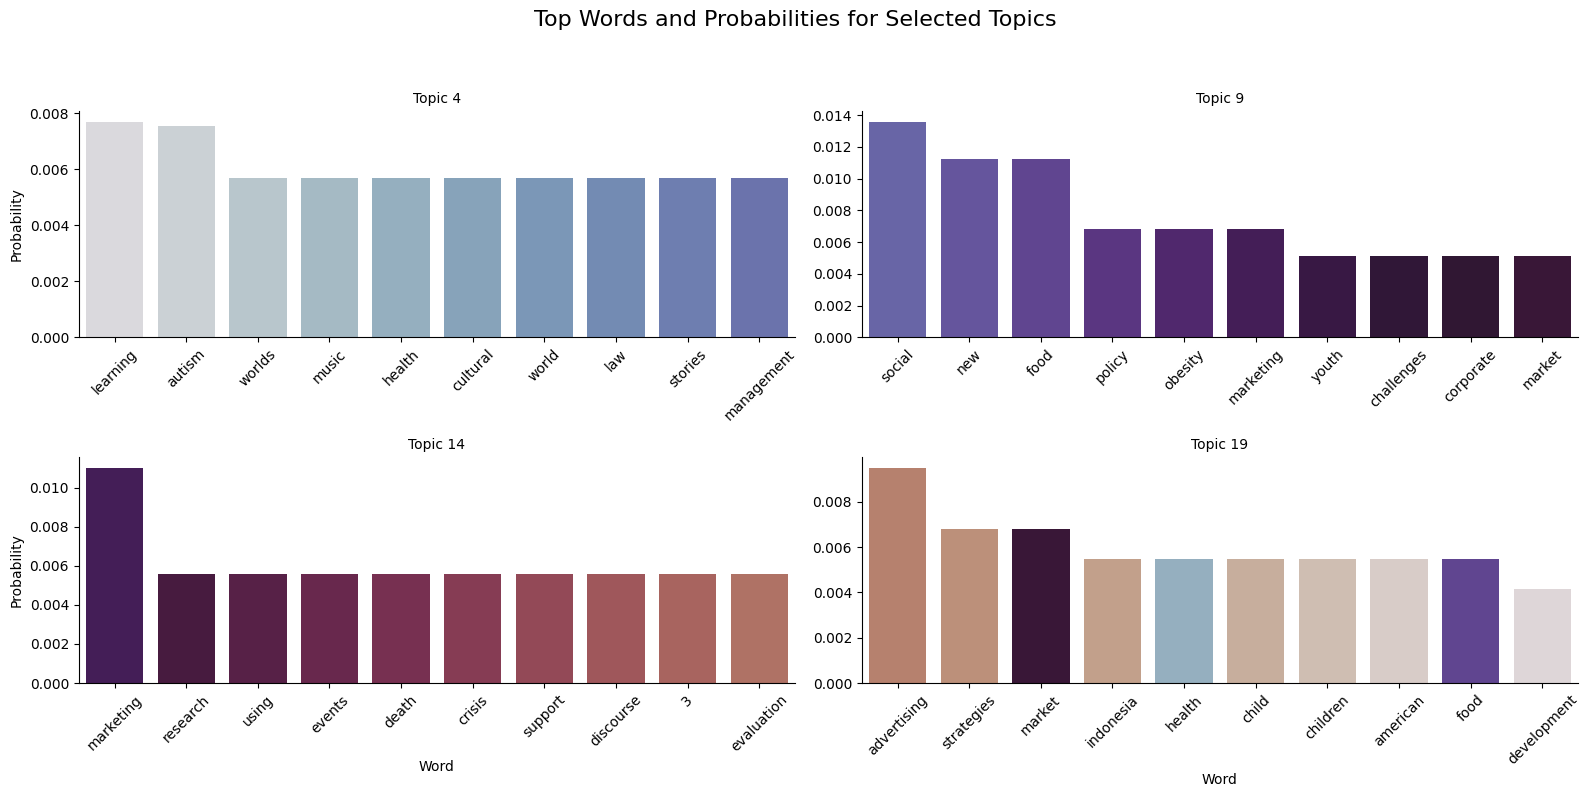

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [152]:
vis = pyLDAvis.gensim_models.prepare(lda_10, corpus, id2word, mds="mmds", R=20)

In [153]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.185177 -0.077397       1        1  13.636552
5      0.012926  0.063656       2        1  11.451133
9     -0.116891  0.146509       3        1  11.040985
8      0.094768 -0.099500       4        1  10.207792
2      0.181598 -0.041196       5        1   9.763029
1      0.154416  0.097141       6        1   9.502377
0      0.028749  0.178724       7        1   9.130619
7      0.020839 -0.185864       8        1   8.598724
3     -0.129901  0.026315       9        1   8.570739
4     -0.061328 -0.108387      10        1   8.098050, topic_info=            Term       Freq      Total Category  logprob  loglift
95        health  26.000000  26.000000  Default  20.0000  20.0000
180      obesity  10.000000  10.000000  Default  19.0000  19.0000
133  advertising  20.000000  20.000000  Default  18.0000  18.0000
35         study  27.000000  27.000000  Default  17.0000  17.0000
92    challenges  11.000000  11.000000  Default  16.0000  16.0000
..           ...        ...        ...      ...      ...      ...
790    childrens   2.210039  16.845899  Topic10  -5.6440   0.4824
32        online   1.975358  12.806593  Topic10  -5.7562   0.6443
121     analysis   1.975933  19.151215  Topic10  -5.7559   0.2422
66      consumer   1.975541  21.181277  Topic10  -5.7561   0.1413
62        social   1.975781  30.827753  Topic10  -5.7560  -0.2339

[498 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
2428      7  0.743286  1950s–2010s
1889      3  0.490291         2017
3160      8  0.508890    abstracts
676       7  0.496634     academic
132       8  0.756958    according
...     ...       ...          ...
335       5  0.146603            –
335       6  0.439809            –
335       7  0.146603            –
335       8  0.146603            –
2319      2  0.729013         ‘all

[1134 rows x 3 columns], R=20, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 6, 10, 9, 3, 2, 1, 8, 4, 5])

I'd say that there are a couple of things that fufill my expectations. But there are a few things that I'm surprised about. Such as topics about food/obesity and sex and all the discussion about the tech field such as models and social media. This is however understandable, sex toys are easily going to show up as results for broad toy categories (especially for academic studies), and there's a lot of discussion about how internet access is slowly lowering the maximum age that children are interested in toys.

Conclusion: Overall, this wasn't the most difficult thing since the materials you gave me were very useful for fufilling the tasks. I didn't really have many 'issues', just took a little elbow grease. I can see myself using this for finding adequite scholarly sources for higher levels of research in the future.